In [1]:
import numpy as np
from tqdm.auto import tqdm

from utils.plot import *

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader

In [2]:
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

print("Using PyTorch version: {}, Device: {}".format(torch.__version__, DEVICE))

Using PyTorch version: 1.12.0, Device: cpu


In [3]:
# ----- Utils -----

In [3]:
def train(model, train_loader, optimizer, scheduler = None):
    model.train()
    train_loss = 0
    correct = 0
    tqdm_bar = tqdm(enumerate(train_loader))
    for batch_idx, (image, label) in tqdm_bar:
        image = image.to(DEVICE)
        label = label.to(DEVICE)
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, label)
        loss.backward()
        train_loss += loss.item()
        prediction = output.max(1, keepdim = True)[1]
        correct += prediction.eq(label.view_as(prediction)).sum().item()
        optimizer.step()
        tqdm_bar.set_description("Epoch {} - train loss: {:.6f}".format(epoch, loss.item()))
    if scheduler is not None:
        scheduler.step()
    train_loss /= len(train_loader.dataset)
    train_acc = 100. * correct / len(train_loader.dataset)
    return train_loss, train_acc

def evaluate(model, test_loader):
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for image, label in tqdm(test_loader):
            image = image.to(DEVICE)
            label = label.to(DEVICE)
            output = model(image)
            test_loss += criterion(output, label).item()
            prediction = output.max(1, keepdim = True)[1]
            correct += prediction.eq(label.view_as(prediction)).sum().item()
    
    test_loss /= len(test_loader.dataset)
    test_acc = 100. * correct / len(test_loader.dataset)
    return test_loss, test_acc

In [4]:
# ----- Load Fashion MNIST -----

In [5]:
BATCH_SIZE = 1024

train_loader = DataLoader(datasets.FashionMNIST('./data/',
                          train=True, download=True,
                          transform=transforms.Compose([transforms.ToTensor(),
                                                        transforms.Normalize((0.1307,), (0.3081,))])), # train data에서 흑,백의 평균값이 0.1307, 0.3081 -> mean centered
                          batch_size=BATCH_SIZE, shuffle=True)

test_loader = DataLoader(datasets.FashionMNIST('./data/',
                          train=False,
                          transform=transforms.Compose([transforms.ToTensor(),
                                                        transforms.Normalize((0.1307,), (0.3081,))])),
                          batch_size=BATCH_SIZE, shuffle=True)

/Users/jeongmoonwon/opt/anaconda3/lib/python3.8/site-packages/torchvision/datasets/mnist.py:498: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:178.)
  return torch.from_numpy(parsed.astype(m[2], copy=False)).view(*s)


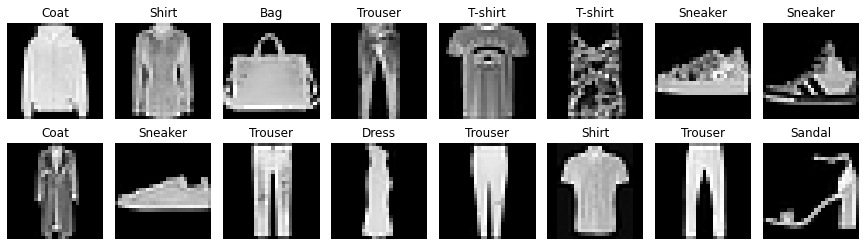

In [6]:
FashionMNIST_plot_dataset(train_loader)

In [8]:
# ----- Custom Dropout -----

In [9]:
# 1. numpy
w1 = np.array([[.2, -.5, .1, 2.],
              [1.5, 1.3, 2.1, 0.],
              [0., .25, .2, -.3]])
data = np.array([56, 231, 24, 2]).reshape(4, 1)
b1 = np.array([1.1, 3.2, -1.2]).reshape(3, 1)

w2 = np.array([.3, 1.5, -.5]).reshape(1, 3)
b2 = 0.8

p = 0.5

def train_step(data, p):
    h1 = np.maximum(0, np.dot(w1, data) + b1) 
    print(h1, 'h1')
    u1 = (np.random.rand(*h1.shape) < p) / p # h1의 값들 중 일부가 사라지므로 h2의 값이 전반적으로 줄어들텐데 이를 방지하기 위해 p로 나눠사 깂을 늘림
    print(u1, 'u1')
    h1 *= u1 # True이면 1을 곱하고 False이먄 0을 곱함으로써 dropout
    print(h1, 'h1')
    h2 = np.maximum(0, np.dot(w2, h1) + b2) # h1의 값들 중 일부가 사라지므로 h2의 값이 전반적으로 줄어들 것임
    print(h2, 'h2')
    u2 = (np.random.rand(*h2.shape) < p) / p
    print(u2, 'u2')
    h2 *= u2
    print(h2, 'h2')

def test_step(data):
    h1 = np.maximum(0, np.dot(w1, data) + b1) # test에서는 p와 무관하게 작동하도록 함
    print('h1', h1)
    h2 = np.maximum(0, np.dot(w2, h1) + b2) 
    print('h2', h2)
    
train_step(data, p)
test_step(data)

[[  0.  ]
 [437.9 ]
 [ 60.75]] h1
[[0.]
 [2.]
 [2.]] u1
[[  0. ]
 [875.8]
 [121.5]] h1
[[1253.75]] h2
[[2.]] u2
[[2507.5]] h2
h1 [[  0.  ]
 [437.9 ]
 [ 60.75]]
h2 [[627.275]]


In [10]:
# 2. pytorch
class Dropout(nn.Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()
        if p < 0 or p > 1:
            raise ValueError("dropout probability has to be between 0 and 1, "
                             "but got {}".format(p))
        self.p = p

    def forward(self, input):
        mask = (np.random.rand(*input.shape) < self.p) / self.p
        output = input * torch.Tensor(mask).to(DEVICE)
        return output.to(DEVICE)

    def __repr__(self):
        return self.__class__.__name__ + '(' + 'p=' + str(self.p) + ')'

In [11]:
# 예시로 확인
x = torch.rand((3, 2)).to(DEVICE)
Dropout(p=0.5)(x)

tensor([[0.0000, 0.0000],
        [0.0000, 0.0000],
        [1.6691, 0.0000]], device='cuda:0')

In [ ]:
# dropout ratio에 따른 결과 비교하기
class RegClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784,256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128,64)
        self.fc4 = nn.Linear(64,10)
        self.dropout = Dropout(p=0) # dropout 하지 않는 경우
        # self.dropout = Dropout(p=0.3) # dropout ratio를  0.3으로 하는 경우
        # self.dropout = Dropout(p=0.7) # dropout ratio가 0.7인 경우 (too high)
    
    def forward(self,x):
        x = x.view(x.shape[0],-1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        x = F.log_softmax(self.fc4(x),dim=1)
        
        return x

In [ ]:
EPOCHS = 20
model = RegClassifier().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
criterion = nn.CrossEntropyLoss()
history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'lr':[]}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = train(model, train_loader, optimizer)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tLR: {:.4f}, \tTrain Loss: {:.4f}, \tTrain Accuracy: {:.2f} %, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, optimizer.param_groups[0]['lr'], train_loss, train_accuracy, test_loss, test_accuracy))
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    
plot_history(history)

In [13]:
# ----- Add regularization to the model -----

In [7]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=8),
            nn.ReLU(),
            nn.Dropout(p=0.3), # 우리가 구현한 Dropout 클래스 대신 nn.dropout 사용 가능
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Flatten(),
            nn.Linear(3136, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, 10),
        )
    
    def forward(self,x):
        x = self.conv(x)
        return x

0it [00:00, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]


[EPOCH: 1], 	LR: 0.0009, 	Train Loss: 0.0007, 	Train Accuracy: 74.47 %, 	Test Loss: 0.0005, 	Test Accuracy: 84.29 % 



0it [00:00, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]


[EPOCH: 9], 	LR: 0.0004, 	Train Loss: 0.0003, 	Train Accuracy: 89.27 %, 	Test Loss: 0.0003, 	Test Accuracy: 88.86 % 



0it [00:00, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]


[EPOCH: 10], 	LR: 0.0003, 	Train Loss: 0.0003, 	Train Accuracy: 89.38 %, 	Test Loss: 0.0003, 	Test Accuracy: 89.16 % 



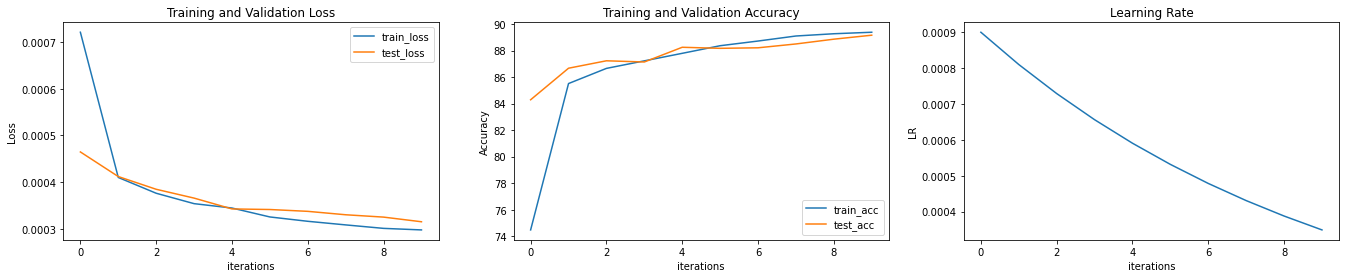

In [8]:
# early stopping, weight_decay, lr_scheduler
from torch.optim.lr_scheduler import ExponentialLR as ExponentialLR

EPOCHS = 10
best_loss = 1000 # 초기값 설정
patience = 0
history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'lr':[]}

model = Model().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001, weight_decay=0.01) # weight_decay - L1, L2 regularization
scheduler = ExponentialLR(optimizer, gamma=0.9) # lr 조정
criterion = nn.CrossEntropyLoss()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = train(model, train_loader, optimizer, scheduler)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tLR: {:.4f}, \tTrain Loss: {:.4f}, \tTrain Accuracy: {:.2f} %, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, optimizer.param_groups[0]['lr'], train_loss, train_accuracy, test_loss, test_accuracy))

    # test_loss가 증가하는 시점에서 early stopping
    if test_loss < best_loss:
        best_loss = test_loss
        patience = 0
    else:
        patience += 1
        if patience >= 5:
            break

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    
plot_history(history)